Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (ContractiveDense)            │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0755 - val_loss: 0.0676
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0662 - val_loss: 0.0634
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0617 - val_loss: 0.0608
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0594 - val_loss: 0.0568
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0548 - val_loss: 0.0515
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0493 - val_loss: 0.0454
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0433 - val_loss: 0.0407
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0400 - val_loss: 0.0388
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0384 - val_loss: 0.0372
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0364 - val_loss: 0.0347
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0341 - val_loss: 0.0324
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/ste

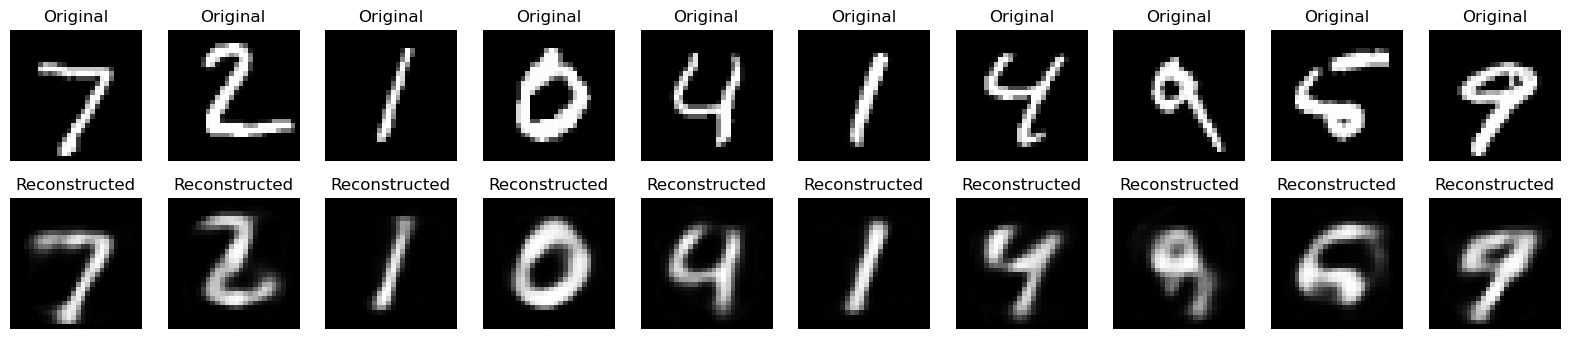

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


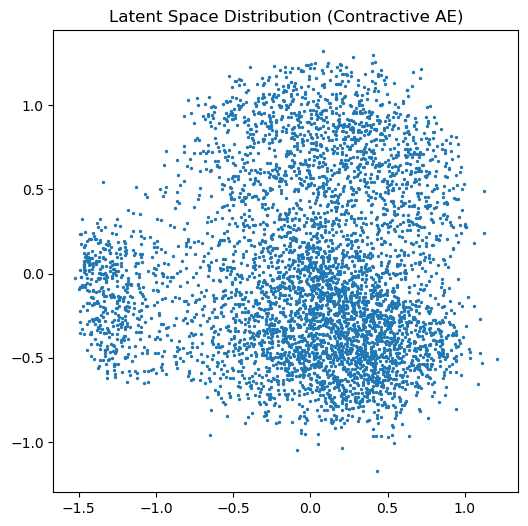

In [ ]:

#Import
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt



#Custom Contractive Dense Layer
# ================================
class ContractiveDense(Dense):
    def __init__(self, units, lambda_c=1e-4, **kwargs):
        super().__init__(units, activation='sigmoid', **kwargs)
        self.lambda_c = lambda_c

    def call(self, inputs):
        # Forward pass
        h = super().call(inputs)

        # dh/dx for sigmoid activation
        dh = h * (1 - h)

        # Frobenius norm approximation of Jacobian
        contractive_loss = self.lambda_c * tf.reduce_sum(
            tf.square(self.kernel)
        ) * tf.reduce_mean(tf.square(dh))

        # Add contractive penalty to model loss
        self.add_loss(contractive_loss)

        return h


# ================================
# 3️⃣ Load & Prepare MNIST
# ================================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.reshape(-1, 784).astype("float32") / 255.
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.


# ================================
# 4️⃣ Build Contractive Autoencoder
# ================================
input_dim = 784
encoding_dim = 32
lambda_c = 1e-4

input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='sigmoid')(input_img)
latent  = ContractiveDense(encoding_dim, lambda_c=lambda_c, name="latent")(encoded)

# Decoder
decoded = Dense(128, activation='sigmoid')(latent)
output  = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_img, output)

# Separate encoder model (for visualization later)
encoder = Model(input_img, latent)


# ================================
# 5️⃣ Compile
# ================================
# IMPORTANT: only reconstruction loss here
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()


# ================================
# 6️⃣ Train
# ================================
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)


# ================================
# 7️⃣ Reconstruct Test Images
# ================================
decoded_imgs = autoencoder.predict(x_test)


# ================================
# 8️⃣ Visualize Reconstructions
# ================================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()


# ================================
# 9️⃣ Visualize Latent Space (2D via PCA)
# ================================
from sklearn.decomposition import PCA

latent_vectors = encoder.predict(x_test[:5000])
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(6,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], s=2)
plt.title("Latent Space Distribution (Contractive AE)")
plt.show()